In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Generate sample data with clusters and noise
def generate_data():
    # Cluster 1: centered at (2, 2)
    cluster1 = torch.randn(40, 2) * 0.4 + torch.tensor([2.0, 2.0])
    
    # Cluster 2: centered at (7, 3)
    cluster2 = torch.randn(40, 2) * 0.5 + torch.tensor([7.0, 3.0])
    
    # Cluster 3: centered at (5, 8)
    cluster3 = torch.randn(35, 2) * 0.4 + torch.tensor([5.0, 8.0])
    
    # Add some noise points (outliers)
    noise = torch.rand(10, 2) * 10.0  # Random points in [0, 10] range
    
    # Combine all data
    data = torch.cat([cluster1, cluster2, cluster3, noise], dim=0)
    
    # Shuffle
    indices = torch.randperm(data.shape[0])
    data = data[indices]
    
    return data

# Generate data
X = generate_data()
print(f"Data shape: {X.shape}")
print(f"First 5 data points:\n{X[:5]}")

Data shape: torch.Size([125, 2])
First 5 data points:
tensor([[8.5960, 2.6362],
        [4.3698, 8.9003],
        [5.5155, 8.0209],
        [7.6674, 3.2418],
        [7.0054, 2.8306]])


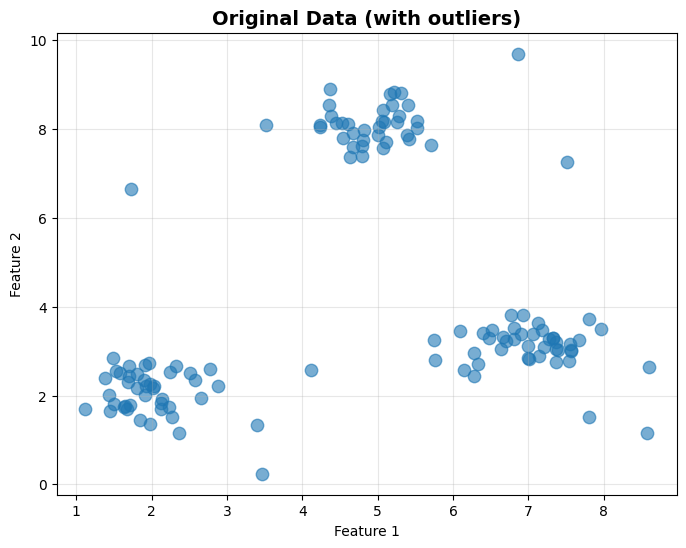

In [3]:
# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=80)
plt.title('Original Data (with outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class DBSCAN:
    def __init__(self, epsilon=0.5, min_samples=5):
        """
        DBSCAN clustering implementation from scratch
        
        Parameters:
        -----------
        epsilon : float
            Maximum distance between two points to be considered neighbors
        min_samples : int
            Minimum number of points to form a dense region (core point)
        """
        self.epsilon = epsilon
        self.min_samples = min_samples
        self.labels = None
        self.core_sample_indices = []
        
    def compute_distances(self, X):
        """
        Compute pairwise Euclidean distances between all points
        
        Returns:
        --------
        distances : torch.Tensor
            Distance matrix of shape (n_samples, n_samples)
        """
        n_samples = X.shape[0]
        
        # Expand dimensions for broadcasting
        # X: (n_samples, n_features) -> (n_samples, 1, n_features)
        X_expanded = X.unsqueeze(1)  # (n_samples, 1, n_features)
        X_transposed = X.unsqueeze(0)  # (1, n_samples, n_features)
        
        # Compute squared Euclidean distances
        distances = torch.sum((X_expanded - X_transposed) ** 2, dim=2)
        distances = torch.sqrt(distances)
        
        return distances
    
    def find_neighbors(self, point_idx, distances):
        """
        Find all neighbors of a point within epsilon distance
        
        Parameters:
        -----------
        point_idx : int
            Index of the point
        distances : torch.Tensor
            Distance matrix
        
        Returns:
        --------
        neighbors : list
            Indices of neighboring points
        """
        # Find points within epsilon distance
        neighbors = torch.where(distances[point_idx] <= self.epsilon)[0].tolist()
        return neighbors
    
    def expand_cluster(self, point_idx, neighbors, cluster_id, distances, visited):
        """
        Expand cluster by adding all density-reachable points
        
        Parameters:
        -----------
        point_idx : int
            Index of the core point
        neighbors : list
            Initial neighbors of the core point
        cluster_id : int
            ID of the current cluster
        distances : torch.Tensor
            Distance matrix
        visited : list
            List of visited point indices
        """
        # Assign cluster to the core point
        self.labels[point_idx] = cluster_id
        
        # Process all neighbors
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]
            
            # If neighbor not visited, mark as visited and check if it's a core point
            if neighbor_idx not in visited:
                visited.append(neighbor_idx)
                
                # Find neighbors of this neighbor
                neighbor_neighbors = self.find_neighbors(neighbor_idx, distances)
                
                # If this neighbor is also a core point, add its neighbors to expansion
                if len(neighbor_neighbors) >= self.min_samples:
                    # Add to core samples
                    if neighbor_idx not in self.core_sample_indices:
                        self.core_sample_indices.append(neighbor_idx)
                    
                    # Merge neighbors (density-reachable points)
                    for nn in neighbor_neighbors:
                        if nn not in neighbors:
                            neighbors.append(nn)
            
            # Assign cluster label if not already assigned
            if self.labels[neighbor_idx] == -1:
                self.labels[neighbor_idx] = cluster_id
            
            i += 1
    
    def fit(self, X):
        """
        Fit DBSCAN to data
        
        Parameters:
        -----------
        X : torch.Tensor
            Data of shape (n_samples, n_features)
        """
        n_samples = X.shape[0]
        
        print(f"Running DBSCAN with epsilon={self.epsilon}, min_samples={self.min_samples}")
        print(f"Number of samples: {n_samples}\n")
        
        # Initialize all labels as noise (-1)
        self.labels = torch.full((n_samples,), -1, dtype=torch.long)
        
        # Compute pairwise distances
        print("Computing pairwise distances...")
        distances = self.compute_distances(X)
        
        # Track visited points
        visited = []
        cluster_id = 0
        
        print("Clustering...\n")
        
        # Process each point
        for point_idx in range(n_samples):
            # Skip if already visited
            if point_idx in visited:
                continue
            
            visited.append(point_idx)
            
            # Find neighbors
            neighbors = self.find_neighbors(point_idx, distances)
            
            # Check if it's a core point
            if len(neighbors) >= self.min_samples:
                # It's a core point - start a new cluster
                self.core_sample_indices.append(point_idx)
                
                if cluster_id < 5:  # Print first few clusters
                    print(f"Cluster {cluster_id}: Starting from point {point_idx} "
                          f"with {len(neighbors)} neighbors")
                
                self.expand_cluster(point_idx, neighbors, cluster_id, distances, visited)
                cluster_id += 1
            else:
                # Not enough neighbors - remains as noise (for now)
                # It might be assigned to a cluster later if it's a border point
                pass
        
        # Count points in each category
        n_clusters = cluster_id
        n_noise = torch.sum(self.labels == -1).item()
        
        print(f"\nClustering complete!")
        print(f"Number of clusters found: {n_clusters}")
        print(f"Number of core points: {len(self.core_sample_indices)}")
        print(f"Number of noise points: {n_noise}")
        
        # Print cluster sizes
        print(f"\nCluster sizes:")
        for i in range(n_clusters):
            count = torch.sum(self.labels == i).item()
            print(f"  Cluster {i}: {count} points")
        
        return self
    
    def predict(self, X):
        """
        Return cluster labels
        """
        return self.labels

In [5]:
# Create and train DBSCAN
dbscan = DBSCAN(epsilon=0.6, min_samples=5)
dbscan.fit(X)

# Get predictions
labels = dbscan.predict(X)

Running DBSCAN with epsilon=0.6, min_samples=5
Number of samples: 125

Computing pairwise distances...
Clustering...

Cluster 0: Starting from point 2 with 13 neighbors
Cluster 1: Starting from point 3 with 16 neighbors
Cluster 2: Starting from point 7 with 18 neighbors

Clustering complete!
Number of clusters found: 3
Number of core points: 110
Number of noise points: 10

Cluster sizes:
  Cluster 0: 35 points
  Cluster 1: 40 points
  Cluster 2: 40 points


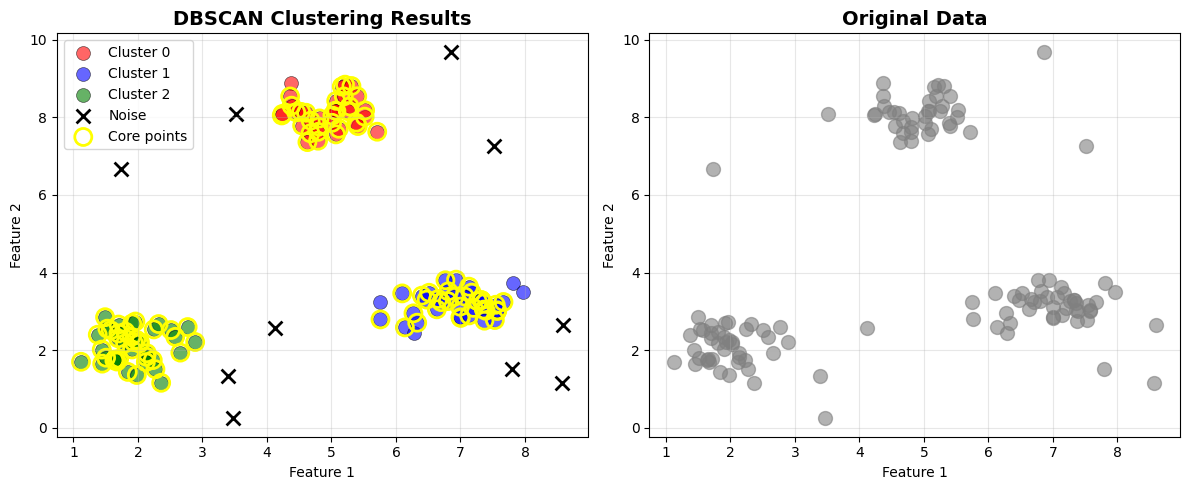

In [6]:
# Visualize clustering results
plt.figure(figsize=(12, 5))

# Plot 1: Clusters with noise
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink']
n_clusters = int(labels.max().item()) + 1

# Plot each cluster
for i in range(n_clusters):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i % len(colors)], label=f'Cluster {i}', 
                alpha=0.6, s=100, edgecolors='black', linewidths=0.5)

# Plot noise points
noise_points = X[labels == -1]
if len(noise_points) > 0:
    plt.scatter(noise_points[:, 0], noise_points[:, 1], 
                c='black', marker='x', s=100, label='Noise', linewidths=2)

# Highlight core points
core_points = X[dbscan.core_sample_indices]
plt.scatter(core_points[:, 0], core_points[:, 1], 
            facecolors='none', edgecolors='yellow', s=150, 
            linewidths=2, label='Core points')

plt.title('DBSCAN Clustering Results', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Original data for comparison
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, c='gray', s=100)
plt.title('Original Data', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("=" * 60)
print("SIMPLE EXAMPLE: 6 Points")
print("=" * 60)

# Create simple data with 6 points
# Points 1-3 form a cluster, Points 4-5 form another cluster, Point 6 is noise
simple_data = torch.tensor([
    [1.0, 1.0],   # P1 - Core
    [1.2, 1.5],   # P2 - Core/Border
    [1.5, 1.0],   # P3 - Core/Border
    [5.0, 5.0],   # P4 - Core
    [5.3, 5.2],   # P5 - Core/Border
    [8.0, 2.0]    # P6 - Noise (isolated)
])

print(f"\nData points:")
for i, point in enumerate(simple_data):
    print(f"  P{i+1}: {point.tolist()}")

# Show pairwise distances
print("\n" + "-" * 60)
print("Pairwise distances:")
print("-" * 60)
for i in range(len(simple_data)):
    for j in range(i + 1, len(simple_data)):
        dist = torch.sqrt(torch.sum((simple_data[i] - simple_data[j]) ** 2))
        print(f"Distance P{i+1} to P{j+1}: {dist:.4f}")

print()

SIMPLE EXAMPLE: 6 Points

Data points:
  P1: [1.0, 1.0]
  P2: [1.2000000476837158, 1.5]
  P3: [1.5, 1.0]
  P4: [5.0, 5.0]
  P5: [5.300000190734863, 5.199999809265137]
  P6: [8.0, 2.0]

------------------------------------------------------------
Pairwise distances:
------------------------------------------------------------
Distance P1 to P2: 0.5385
Distance P1 to P3: 0.5000
Distance P1 to P4: 5.6569
Distance P1 to P5: 6.0108
Distance P1 to P6: 7.0711
Distance P2 to P3: 0.5831
Distance P2 to P4: 5.1662
Distance P2 to P5: 5.5227
Distance P2 to P6: 6.8184
Distance P3 to P4: 5.3151
Distance P3 to P5: 5.6639
Distance P3 to P6: 6.5765
Distance P4 to P5: 0.3606
Distance P4 to P6: 4.2426
Distance P5 to P6: 4.1869



In [8]:
# Apply DBSCAN with epsilon=0.8, min_samples=2
print("\n" + "=" * 60)
print("APPLYING DBSCAN (epsilon=0.8, min_samples=2)")
print("=" * 60 + "\n")

dbscan_simple = DBSCAN(epsilon=0.8, min_samples=2)
dbscan_simple.fit(simple_data)
simple_labels = dbscan_simple.predict(simple_data)

print(f"\nFinal cluster assignments:")
for i, label in enumerate(simple_labels):
    label_str = f"Cluster {label.item()}" if label.item() != -1 else "Noise"
    is_core = "(Core)" if i in dbscan_simple.core_sample_indices else "(Border/Noise)"
    print(f"  P{i+1} -> {label_str} {is_core}")


APPLYING DBSCAN (epsilon=0.8, min_samples=2)

Running DBSCAN with epsilon=0.8, min_samples=2
Number of samples: 6

Computing pairwise distances...
Clustering...

Cluster 0: Starting from point 0 with 3 neighbors
Cluster 1: Starting from point 3 with 2 neighbors

Clustering complete!
Number of clusters found: 2
Number of core points: 5
Number of noise points: 1

Cluster sizes:
  Cluster 0: 3 points
  Cluster 1: 2 points

Final cluster assignments:
  P1 -> Cluster 0 (Core)
  P2 -> Cluster 0 (Core)
  P3 -> Cluster 0 (Core)
  P4 -> Cluster 1 (Core)
  P5 -> Cluster 1 (Core)
  P6 -> Noise (Border/Noise)


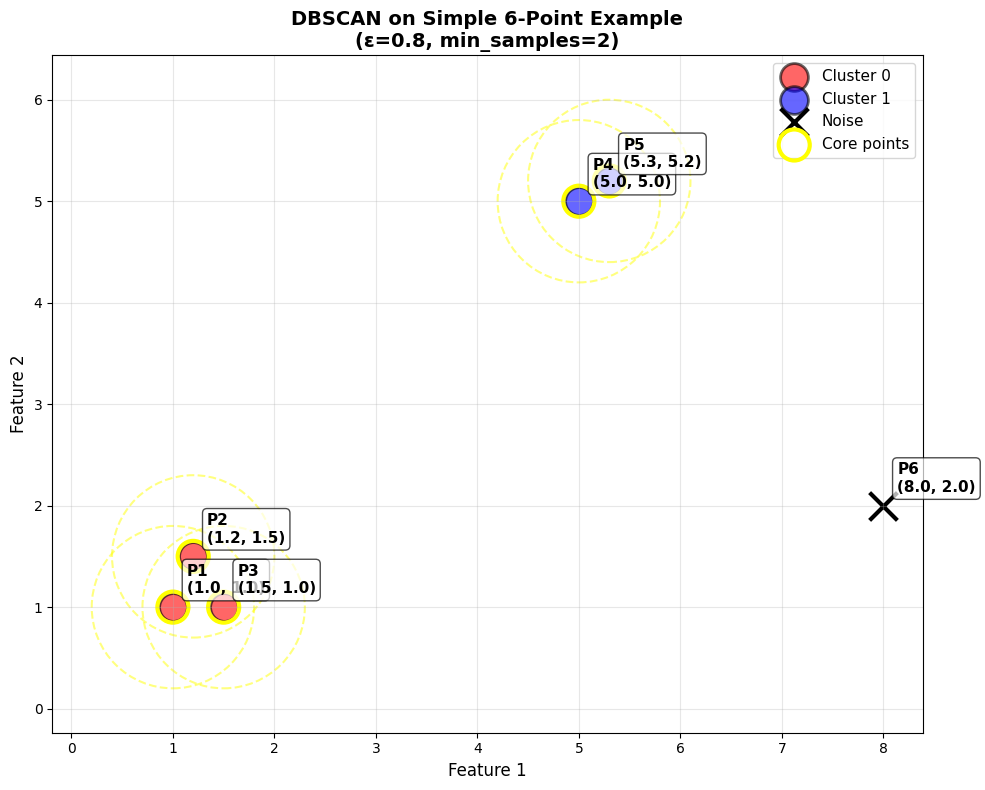

In [9]:
# Visualize simple example
plt.figure(figsize=(10, 8))

colors_simple = ['red', 'blue', 'green', 'orange']
n_clusters_simple = int(simple_labels.max().item()) + 1

# Plot clusters
for i in range(n_clusters_simple):
    cluster_points = simple_data[simple_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors_simple[i], s=400, label=f'Cluster {i}', 
                alpha=0.6, edgecolors='black', linewidths=2)

# Plot noise points
noise_points_simple = simple_data[simple_labels == -1]
if len(noise_points_simple) > 0:
    plt.scatter(noise_points_simple[:, 0], noise_points_simple[:, 1], 
                c='black', marker='x', s=400, label='Noise', linewidths=3)

# Highlight core points
core_points_simple = simple_data[dbscan_simple.core_sample_indices]
plt.scatter(core_points_simple[:, 0], core_points_simple[:, 1], 
            facecolors='none', edgecolors='yellow', s=500, 
            linewidths=3, label='Core points')

# Draw epsilon circles around core points
for idx in dbscan_simple.core_sample_indices:
    circle = plt.Circle(simple_data[idx], dbscan_simple.epsilon, 
                       color='yellow', fill=False, linestyle='--', 
                       linewidth=1.5, alpha=0.5)
    plt.gca().add_patch(circle)

# Annotate points
for i, point in enumerate(simple_data):
    plt.annotate(f'P{i+1}\n({point[0]:.1f}, {point[1]:.1f})', 
                xy=point, xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title(f'DBSCAN on Simple 6-Point Example\n(ε={dbscan_simple.epsilon}, min_samples={dbscan_simple.min_samples})', 
         fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

Running DBSCAN with epsilon=0.4, min_samples=5
Number of samples: 125

Computing pairwise distances...
Clustering...

Cluster 0: Starting from point 2 with 6 neighbors
Cluster 1: Starting from point 3 with 11 neighbors
Cluster 2: Starting from point 7 with 5 neighbors

Clustering complete!
Number of clusters found: 3
Number of core points: 92
Number of noise points: 18

Cluster sizes:
  Cluster 0: 34 points
  Cluster 1: 34 points
  Cluster 2: 39 points
Running DBSCAN with epsilon=0.6, min_samples=5
Number of samples: 125

Computing pairwise distances...
Clustering...

Cluster 0: Starting from point 2 with 13 neighbors
Cluster 1: Starting from point 3 with 16 neighbors
Cluster 2: Starting from point 7 with 18 neighbors

Clustering complete!
Number of clusters found: 3
Number of core points: 110
Number of noise points: 10

Cluster sizes:
  Cluster 0: 35 points
  Cluster 1: 40 points
  Cluster 2: 40 points
Running DBSCAN with epsilon=0.8, min_samples=5
Number of samples: 125

Computing pa

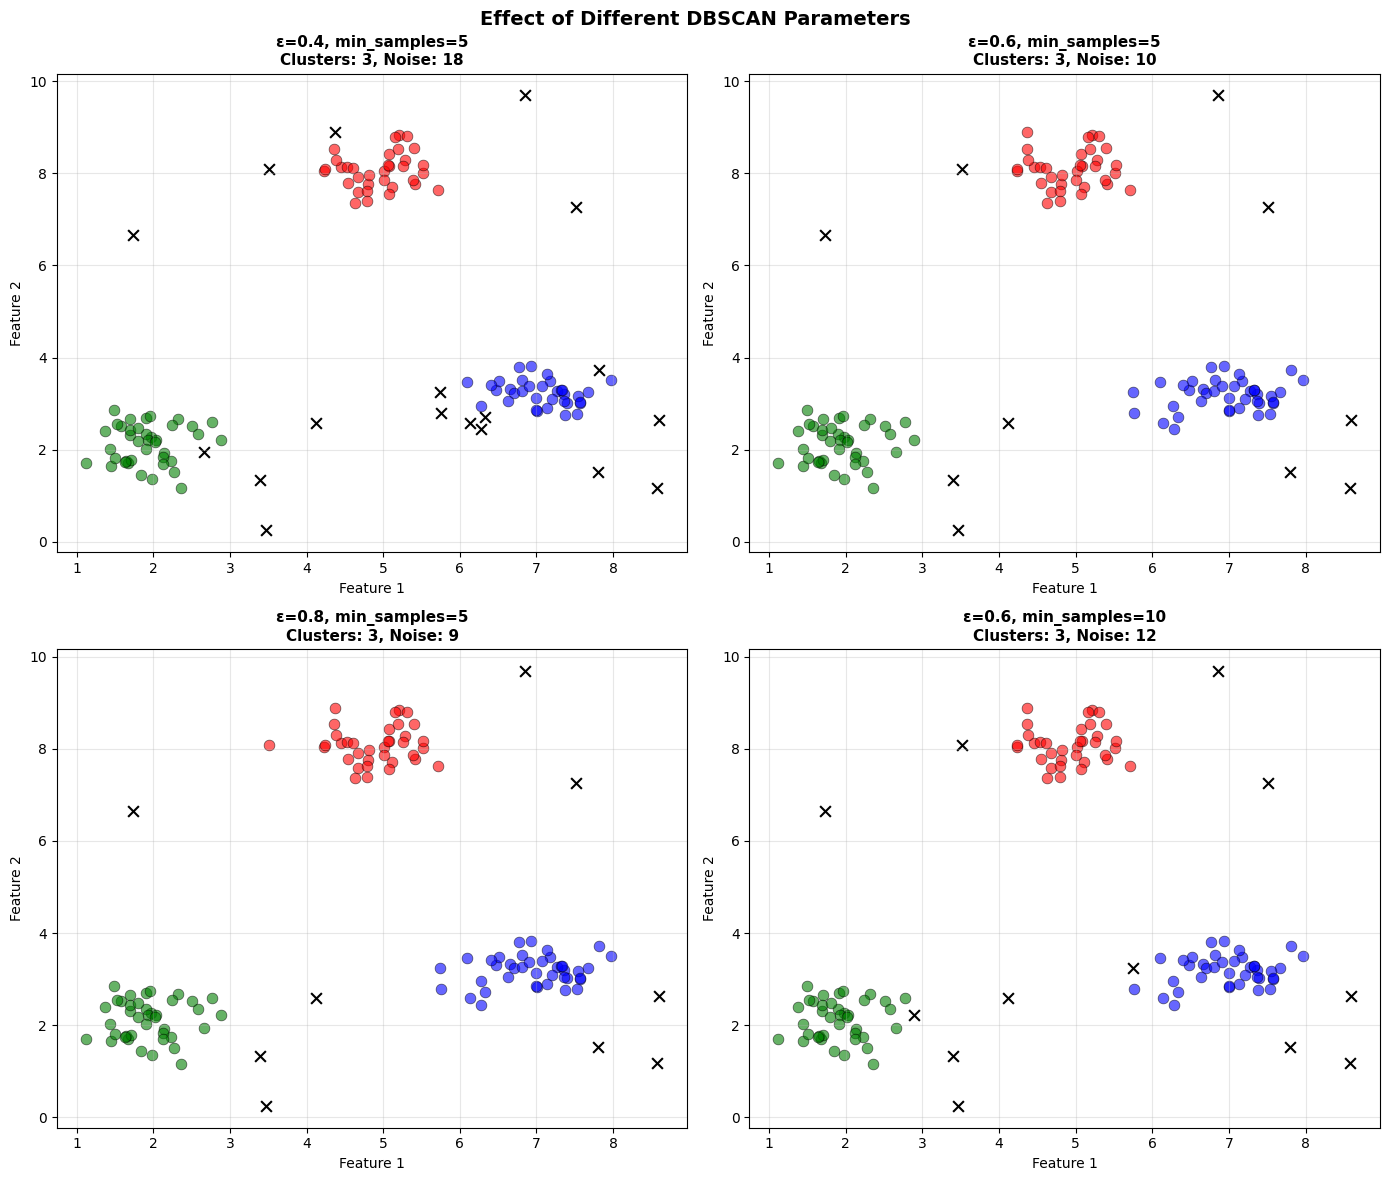


Parameter Effects:
- Small epsilon: More clusters, more noise
- Large epsilon: Fewer clusters, less noise
- High min_samples: Stricter core point criteria, more noise


In [10]:
# Try different epsilon values
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

parameters = [
    (0.4, 5),   # Small epsilon
    (0.6, 5),   # Medium epsilon
    (0.8, 5),   # Large epsilon
    (0.6, 10)   # Medium epsilon, high min_samples
]

for idx, (eps, min_samp) in enumerate(parameters):
    ax = axes[idx]
    
    # Run DBSCAN
    db = DBSCAN(epsilon=eps, min_samples=min_samp)
    db.fit(X)
    labels_temp = db.predict(X)
    
    n_clusters_temp = int(labels_temp.max().item()) + 1
    n_noise_temp = torch.sum(labels_temp == -1).item()
    
    # Plot clusters
    for i in range(n_clusters_temp):
        cluster_points = X[labels_temp == i]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                  c=colors[i % len(colors)], alpha=0.6, s=60, 
                  edgecolors='black', linewidths=0.5)
    
    # Plot noise
    noise_temp = X[labels_temp == -1]
    if len(noise_temp) > 0:
        ax.scatter(noise_temp[:, 0], noise_temp[:, 1], 
                  c='black', marker='x', s=60, linewidths=1.5)
    
    ax.set_title(f'ε={eps}, min_samples={min_samp}\nClusters: {n_clusters_temp}, Noise: {n_noise_temp}', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Different DBSCAN Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nParameter Effects:")
print("- Small epsilon: More clusters, more noise")
print("- Large epsilon: Fewer clusters, less noise")
print("- High min_samples: Stricter core point criteria, more noise")

Point Classification:
  Core points: 110
  Border points: 5
  Noise points: 10
  Total: 125


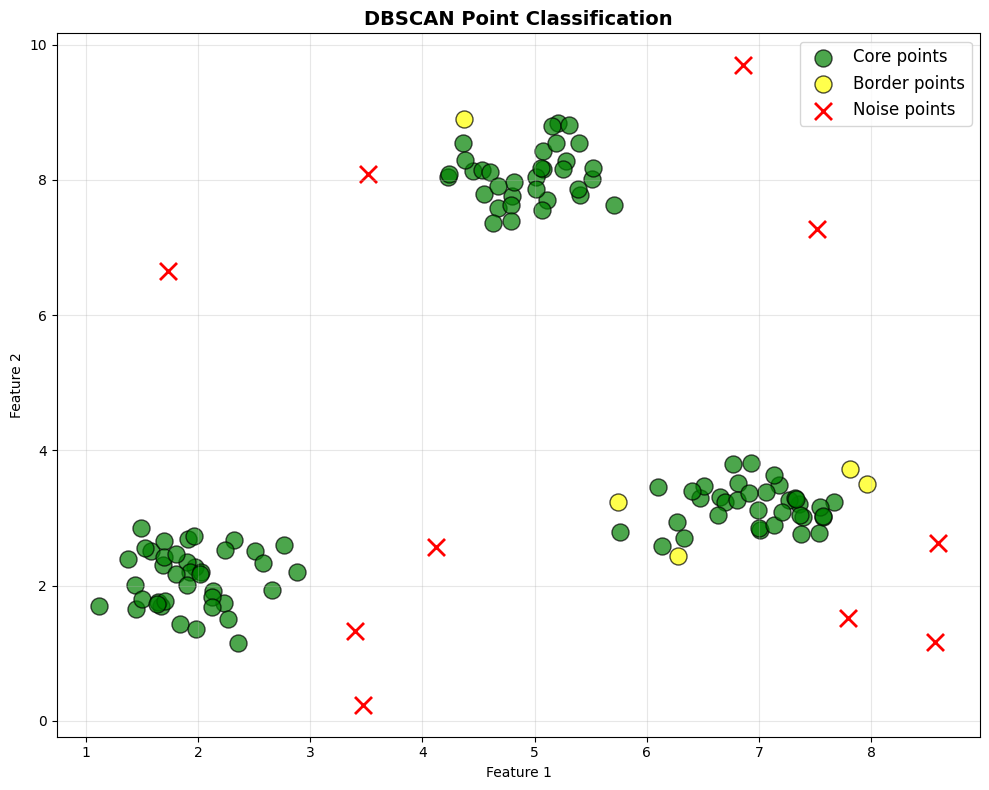

In [11]:
# Classify points from our main example
labels_main = dbscan.predict(X)

core_mask = torch.zeros(len(X), dtype=torch.bool)
for idx in dbscan.core_sample_indices:
    core_mask[idx] = True

border_mask = (labels_main != -1) & (~core_mask)
noise_mask = labels_main == -1

print("Point Classification:")
print(f"  Core points: {core_mask.sum().item()}")
print(f"  Border points: {border_mask.sum().item()}")
print(f"  Noise points: {noise_mask.sum().item()}")
print(f"  Total: {len(X)}")

# Visualize point types
plt.figure(figsize=(10, 8))

# Plot by point type
plt.scatter(X[core_mask, 0], X[core_mask, 1], 
           c='green', s=150, label='Core points', 
           alpha=0.7, edgecolors='black', linewidths=1)

plt.scatter(X[border_mask, 0], X[border_mask, 1], 
           c='yellow', s=150, label='Border points', 
           alpha=0.7, edgecolors='black', linewidths=1)

plt.scatter(X[noise_mask, 0], X[noise_mask, 1], 
           c='red', marker='x', s=150, label='Noise points', 
           linewidths=2)

plt.title('DBSCAN Point Classification', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()